In [1]:
import pyodbc
from sqlalchemy import create_engine
import urllib
import pandas as pd
import numpy as np
import os

# Connect to SQL Server
driver = "ODBC Driver 17 for SQL Server"
server_name = r"LAPTOP-5CHV2K6U\UMASANKAR"
database_name = "ShopSenseDB"

conn_str = (
    f"DRIVER={{{driver}}};"
    f"SERVER={server_name};"
    f"DATABASE={database_name};"
    f"Trusted_Connection=yes;"
    f"TrustServerCertificate=yes;"
)
engine = create_engine(f"mssql+pyodbc:///?odbc_connect={urllib.parse.quote_plus(conn_str)}")

# Query orders with reviews and financials
query = """
SELECT 
    v.order_id,
    v.customer_unique_id,
    v.order_purchase_timestamp,
    v.order_status,
    v.total_item_value,
    v.delivery_days,
    v.is_delayed,
    ISNULL(r.review_score, 4) AS review_score
FROM dbo.vw_order_details v
LEFT JOIN dbo.order_reviews r 
    ON v.order_id = r.order_id
WHERE v.order_status = 'delivered';
"""

with engine.connect() as conn:
    df_raw_orders = pd.read_sql(query, conn)

df_raw_orders["order_purchase_timestamp"] = pd.to_datetime(df_raw_orders["order_purchase_timestamp"])

print(f"✓ Loaded {len(df_raw_orders):,} delivered line items across {df_raw_orders['customer_unique_id'].nunique():,} customers!")

✓ Loaded 110,840 delivered line items across 93,358 customers!


In [2]:
# 1. Define the Cutoff Date (leaving a 6-month prediction horizon)
CUTOFF_DATE = pd.to_datetime("2018-04-01")
print(f"Cutoff Date for Feature Observation: {CUTOFF_DATE.date()}")

# 2. Split data into Historical Observation vs Future Prediction Window
df_history = df_raw_orders[df_raw_orders["order_purchase_timestamp"] < CUTOFF_DATE]
df_future = df_raw_orders[df_raw_orders["order_purchase_timestamp"] >= CUTOFF_DATE]

print(f"Historical Orders (before cutoff): {len(df_history):,}")
print(f"Future Orders (after cutoff):      {len(df_future):,}")

# 3. Identify all customers who bought before the cutoff date
history_customers = df_history["customer_unique_id"].unique()
print(f"\nCohort of Customers active prior to cutoff: {len(history_customers):,}")

# 4. Engineer features strictly from the historical data
customer_features = df_history.groupby("customer_unique_id").agg(
    recency_days=("order_purchase_timestamp", lambda x: (CUTOFF_DATE - x.max()).days),
    historical_orders=("order_id", "nunique"),
    total_spend=("total_item_value", "sum"),
    avg_order_value=("total_item_value", "mean"),
    avg_review_score=("review_score", "mean"),
    avg_delivery_days=("delivery_days", "mean"),
    delayed_orders_count=("is_delayed", "sum")
).reset_index()

# 5. Determine the Target Variable (Y)
# Which historical customers placed an order in the future 6-month window?
future_active_customers = set(df_future["customer_unique_id"].unique())

# Churn Definition: 1 if they DID NOT return in the next 6 months; 0 if they DID return
customer_features["is_churned"] = customer_features["customer_unique_id"].apply(
    lambda cust_id: 0 if cust_id in future_active_customers else 1
)

print("\n--- CHURN TARGET DISTRIBUTION ---")
target_counts = customer_features["is_churned"].value_counts()
target_pct = customer_features["is_churned"].value_counts(normalize=True) * 100

print(f"Retained (0 - Returned to buy):   {target_counts.get(0, 0):,} ({target_pct.get(0, 0):.2f}%)")
print(f"Churned  (1 - Did not return):    {target_counts.get(1, 0):,} ({target_pct.get(1, 0):.2f}%)")
display(customer_features.head())

Cutoff Date for Feature Observation: 2018-04-01
Historical Orders (before cutoff): 74,038
Future Orders (after cutoff):      36,802

Cohort of Customers active prior to cutoff: 62,299

--- CHURN TARGET DISTRIBUTION ---
Retained (0 - Returned to buy):   603 (0.97%)
Churned  (1 - Did not return):    61,696 (99.03%)


,customer_unique_id,recency_days,historical_orders,total_spend,avg_order_value,avg_review_score,avg_delivery_days,delayed_orders_count,is_churned
0,0000f46a3911fa3c0805444483337064,386,1,86.22,86.22,3.0,26.0,0,1
1,0000f6ccb0745a6a4b88665a16c9f078,170,1,43.62,43.62,4.0,20.0,0,1
2,0004aac84e0df4da2b147fca70cf8255,137,1,196.89,196.89,5.0,13.0,0,1
3,00053a61a98854899e70ed204dd4bafe,31,1,419.18,209.59,1.0,16.0,0,1
4,0005e1862207bf6ccc02e4228effd9a0,392,1,150.12,150.12,4.0,5.0,0,1


In [3]:
# Save processed features to data/processed/
PROCESSED_DATA_PATH = os.path.join("..", "data", "processed", "churn_features.csv")
customer_features.to_csv(PROCESSED_DATA_PATH, index=False)
print(f"✓ Saved {len(customer_features):,} customer training rows to [{PROCESSED_DATA_PATH}]!")

✓ Saved 62,299 customer training rows to [..\data\processed\churn_features.csv]!


In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import joblib

# 1. Select Features
feature_cols = [
    "recency_days", 
    "historical_orders", 
    "total_spend", 
    "avg_order_value", 
    "avg_review_score", 
    "avg_delivery_days", 
    "delayed_orders_count"
]

X = customer_features[feature_cols].copy()
y = customer_features["is_churned"]

# 2. Impute any missing values (NaNs) cleanly with medians
for col in feature_cols:
    if X[col].isnull().sum() > 0:
        fill_val = X[col].median()
        X[col] = X[col].fillna(fill_val)
        print(f"Filled missing values in [{col}] with median: {fill_val:.1f}")

# 3. Stratified Train-Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"\nTraining set:   {X_train.shape[0]:,} samples")
print(f"Testing set:    {X_test.shape[0]:,} samples")
print(f"Train Churn %:  {y_train.mean()*100:.2f}%")
print(f"Test Churn %:   {y_test.mean()*100:.2f}%")

# 4. Fit StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\n✓ Features cleaned and scaled with ZERO NaNs!")

Filled missing values in [avg_delivery_days] with median: 12.0

Training set:   49,839 samples
Testing set:    12,460 samples
Train Churn %:  99.03%
Test Churn %:   99.03%

✓ Features cleaned and scaled with ZERO NaNs!


In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score, average_precision_score

models = {
    "Logistic Regression": LogisticRegression(class_weight="balanced", random_state=42, max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=42, n_jobs=-1, max_depth=8),
    "Hist Gradient Boosting": HistGradientBoostingClassifier(random_state=42, max_depth=6)
}

results = []
print("Training & Evaluating Models on holdout test set...\n" + "=" * 65)

for model_name, model in models.items():
    if model_name == "Logistic Regression":
        model.fit(X_train_scaled, y_train)
        y_prob = model.predict_proba(X_test_scaled)[:, 1]
    else:
        model.fit(X_train, y_train)
        y_prob = model.predict_proba(X_test)[:, 1]
        
    roc_auc = roc_auc_score(y_test, y_prob)
    pr_auc = average_precision_score(y_test, y_prob)
    
    results.append({
        "Model": model_name,
        "ROC-AUC Score": round(roc_auc, 4),
        "PR-AUC Score": round(pr_auc, 4)
    })
    print(f"✓ {model_name:<25} | ROC-AUC: {roc_auc:.4f} | PR-AUC: {pr_auc:.4f}")

print("=" * 65)
comparison_df = pd.DataFrame(results).sort_values(by="ROC-AUC Score", ascending=False)
display(comparison_df)

Training & Evaluating Models on holdout test set...
✓ Logistic Regression       | ROC-AUC: 0.5921 | PR-AUC: 0.9931
✓ Random Forest             | ROC-AUC: 0.5458 | PR-AUC: 0.9917
✓ Hist Gradient Boosting    | ROC-AUC: 0.5810 | PR-AUC: 0.9924


,Model,ROC-AUC Score,PR-AUC Score
0,Logistic Regression,0.5921,0.9931
2,Hist Gradient Boosting,0.5810,0.9924
1,Random Forest,0.5458,0.9917


--- CHURN RISK SIGNALS (LOGISTIC REGRESSION COEFFICIENTS) ---


,Feature,Coefficient
3,avg_order_value,0.514851
0,recency_days,0.178400
5,avg_delivery_days,0.117889
6,delayed_orders_count,-0.127869
1,historical_orders,-0.144396
4,avg_review_score,-0.188759
2,total_spend,-0.247914


C:\Users\Uma sankar rao\AppData\Local\Temp\ipykernel_5616\460445845.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=coef_df, x="Coefficient", y="Feature", palette=colors)


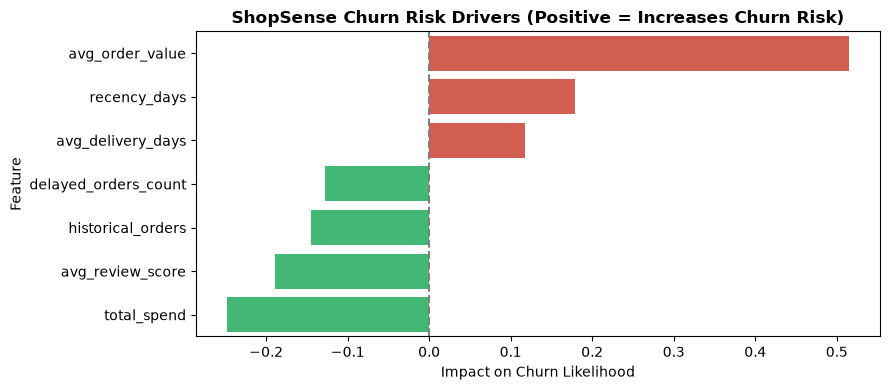

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Extract coefficients from our top-performing Logistic Regression model
best_model = models["Logistic Regression"]

coef_df = pd.DataFrame({
    "Feature": feature_cols,
    "Coefficient": best_model.coef_[0]
}).sort_values(by="Coefficient", ascending=False)

print("--- CHURN RISK SIGNALS (LOGISTIC REGRESSION COEFFICIENTS) ---")
display(coef_df)

# Plot the risk signals
plt.figure(figsize=(9, 4))
colors = ["#e74c3c" if c > 0 else "#2ecc71" for c in coef_df["Coefficient"]]
sns.barplot(data=coef_df, x="Coefficient", y="Feature", palette=colors)
plt.axvline(0, color="grey", linestyle="--")
plt.title("ShopSense Churn Risk Drivers (Positive = Increases Churn Risk)", fontsize=12, weight="bold")
plt.xlabel("Impact on Churn Likelihood")
plt.tight_layout()
plt.show()

In [11]:
import os
import joblib

MODELS_DIR = os.path.join("..", "models")
os.makedirs(MODELS_DIR, exist_ok=True)

# 1. Save the best model
model_path = os.path.join(MODELS_DIR, "churn_model.pkl")
joblib.dump(best_model, model_path)

# 2. Save the Scaler
scaler_path = os.path.join(MODELS_DIR, "churn_scaler.pkl")
joblib.dump(scaler, scaler_path)

# 3. Save the Feature column order
cols_path = os.path.join(MODELS_DIR, "feature_columns.pkl")
joblib.dump(feature_cols, cols_path)

print(f"✓ Best Model saved to:   [{model_path}]")
print(f"✓ Feature Scaler saved: [{scaler_path}]")
print(f"✓ Feature Columns saved: [{cols_path}]")
print("\nPRODUCTION ARTIFACTS READY FOR FASTAPI BACKEND!")

✓ Best Model saved to:   [..\models\churn_model.pkl]
✓ Feature Scaler saved: [..\models\churn_scaler.pkl]
✓ Feature Columns saved: [..\models\feature_columns.pkl]

PRODUCTION ARTIFACTS READY FOR FASTAPI BACKEND!
